In [1]:
# basic libraries
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
# load the dataset
df = pd.read_csv('../data/creditcard.csv')

# check first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# check how many fraud and normal transactions
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

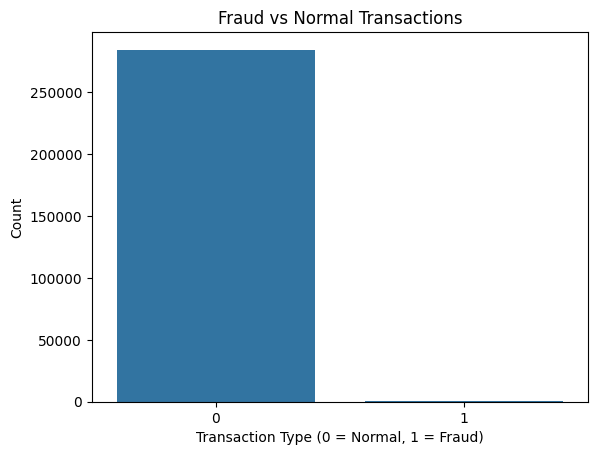

In [5]:
# visualize class distribution
sns.countplot(x='Class', data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Transaction Type (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

In [6]:
# separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# check shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [7]:
# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [8]:
# logistic regression model
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


c:\Users\afifa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
# make predictions on test data
y_pred_lr = lr_model.predict(X_test)

print("Predictions completed")

Predictions completed


In [10]:
# evaluate logistic regression
print(classification_report(y_test, y_pred_lr))

print("ROC AUC Score:", roc_auc_score(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.92      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962

ROC AUC Score: 0.9424068023382678


In [11]:
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [12]:
# predictions using Random Forest
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed")

Random Forest predictions completed


In [13]:
# evaluate Random Forest model
print(classification_report(y_test, y_pred_rf))

print("ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.8724226008636431


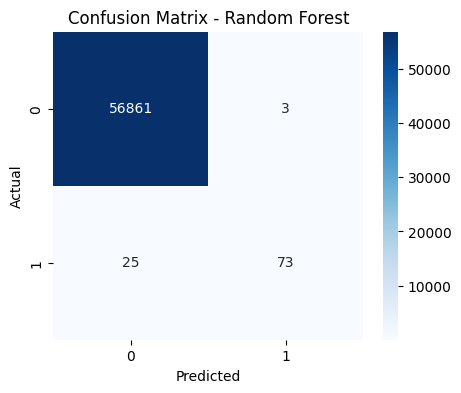

In [14]:
# confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()